In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPUs Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Anemia Detection from Eye Conjunctiva Images using EfficientNetB0

## Dataset
- CP AnemiC Dataset
- Total Images: 710
- Anemic: 424
- Non-Anemic: 286

---

## Research Workflow

1. Environment Setup ✅
2. Dataset Inspection
3. TensorFlow Data Pipeline
4. Data Augmentation
5. EfficientNetB0 Preprocessing
6. Build Baseline Model
7. Training
8. Evaluation
9. Fine-Tuning
10. Hyperparameter Tuning
11. Final Evaluation
12. Grad-CAM
13. Streamlit Deployment

---

## Experiment Log

| Exp ID | Change | Train Acc | Val Acc | Precision | Recall | F1 | ROC-AUC | Decision | Notes |
|--------|--------|-----------|----------|-----------|--------|----|---------|----------|-------|
| E1 | Baseline EfficientNetB0 | - | - | - | - | - | - | In Progress | Frozen backbone |

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from PIL import Image

import os
from pathlib import Path

print("✅ All required libraries imported successfully!")

✅ All required libraries imported successfully!


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

# Path to your dataset in Google Drive
dataset_path = Path("/content/drive/MyDrive/Anemia_Project")

# Check whether the folder exists
print("Dataset exists:", dataset_path.exists())

# List everything inside the dataset folder
print("\nContents of Anemia_Project folder:")
for item in dataset_path.iterdir():
    print("-", item.name)

Dataset exists: True

Contents of Anemia_Project folder:
- Anemia_Data_Collection_Sheet.xlsx
- Non-anemic
- Anemic


In [ ]:
from pathlib import Path

# Define class folders
anemic_path = dataset_path / "Anemic"
non_anemic_path = dataset_path / "Non-anemic"

# Allowed image extensions
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# Count images in each folder
anemic_images = [img for img in anemic_path.iterdir() if img.suffix.lower() in image_extensions]
non_anemic_images = [img for img in non_anemic_path.iterdir() if img.suffix.lower() in image_extensions]

print(f"Anemic Images     : {len(anemic_images)}")
print(f"Non-Anemic Images : {len(non_anemic_images)}")
print(f"Total Images      : {len(anemic_images) + len(non_anemic_images)}")

Anemic Images     : 424
Non-Anemic Images : 286
Total Images      : 710


In [ ]:
import pandas as pd

# Path to the Excel file
excel_path = "/content/drive/MyDrive/Anemia_Project/Anemia_Data_Collection_Sheet.xlsx"

# Read the Excel file
df = pd.read_excel(excel_path)

# Display basic information
print("Shape of the dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Shape of the dataset: (710, 11)

Column Names:
['IMAGE_ID', 'HB_LEVEL', 'Severity', 'Age(Months)', 'GENDER', 'REMARK', 'HOSPITAL', 'CITY/TOWN', 'MUNICIPALITY/DISTRICT', 'REGION', 'COUNTRY']

First 5 Rows:


,IMAGE_ID,HB_LEVEL,Severity,Age(Months),GENDER,REMARK,HOSPITAL,CITY/TOWN,MUNICIPALITY/DISTRICT,REGION,COUNTRY
0,Image_001,9.8,Moderate,6,Female,Anemic,Nkawie-Toase Government Hospital,Nkawie-Toase,Atwima Nwabiagya South,Ashanti,Ghana
1,Image_002,9.9,Moderate,24,Male,Anemic,Ejusu Government Hospital,Ejusu,Ejusu Municipality,Ashanti,Ghana
2,Image_003,11.1,Non-Anemic,24,Female,Non-anemic,Ahmadiyya Muslim Hospital,Tachiman,Techiman Municipality,Bono-East,Ghana
3,Image_004,12.5,Non-Anemic,12,Male,Non-anemic,Ahmadiyya Muslim Hospital,Tachiman,Techiman Municipality,Bono-East,Ghana
4,Image_005,9.9,Moderate,24,Male,Anemic,Sunyani Municipal Hospital,Sunyani,Sunyani Municipality,Bono,Ghana


In [ ]:
from PIL import Image
from collections import Counter

# Store all image resolutions
image_sizes = []

# Read every image from both folders
for image_path in anemic_images + non_anemic_images:

    # Open image safely
    with Image.open(image_path) as img:

        # Store (width, height)
        image_sizes.append(img.size)

# Count each unique resolution
size_counts = Counter(image_sizes)

print("=" * 50)
print("IMAGE RESOLUTION ANALYSIS")
print("=" * 50)

print(f"\nTotal Images Checked : {len(image_sizes)}")

print(f"Unique Resolutions   : {len(size_counts)}")

print("\nTop 10 Most Common Resolutions\n")

for resolution, count in size_counts.most_common(10):
    print(f"{resolution} ---> {count} images")

IMAGE RESOLUTION ANALYSIS

Total Images Checked : 710
Unique Resolutions   : 452

Top 10 Most Common Resolutions

(301, 109) ---> 12 images
(292, 105) ---> 10 images
(430, 225) ---> 10 images
(111, 42) ---> 9 images
(246, 70) ---> 9 images
(220, 88) ---> 9 images
(238, 91) ---> 8 images
(304, 103) ---> 7 images
(198, 103) ---> 7 images
(210, 103) ---> 7 images


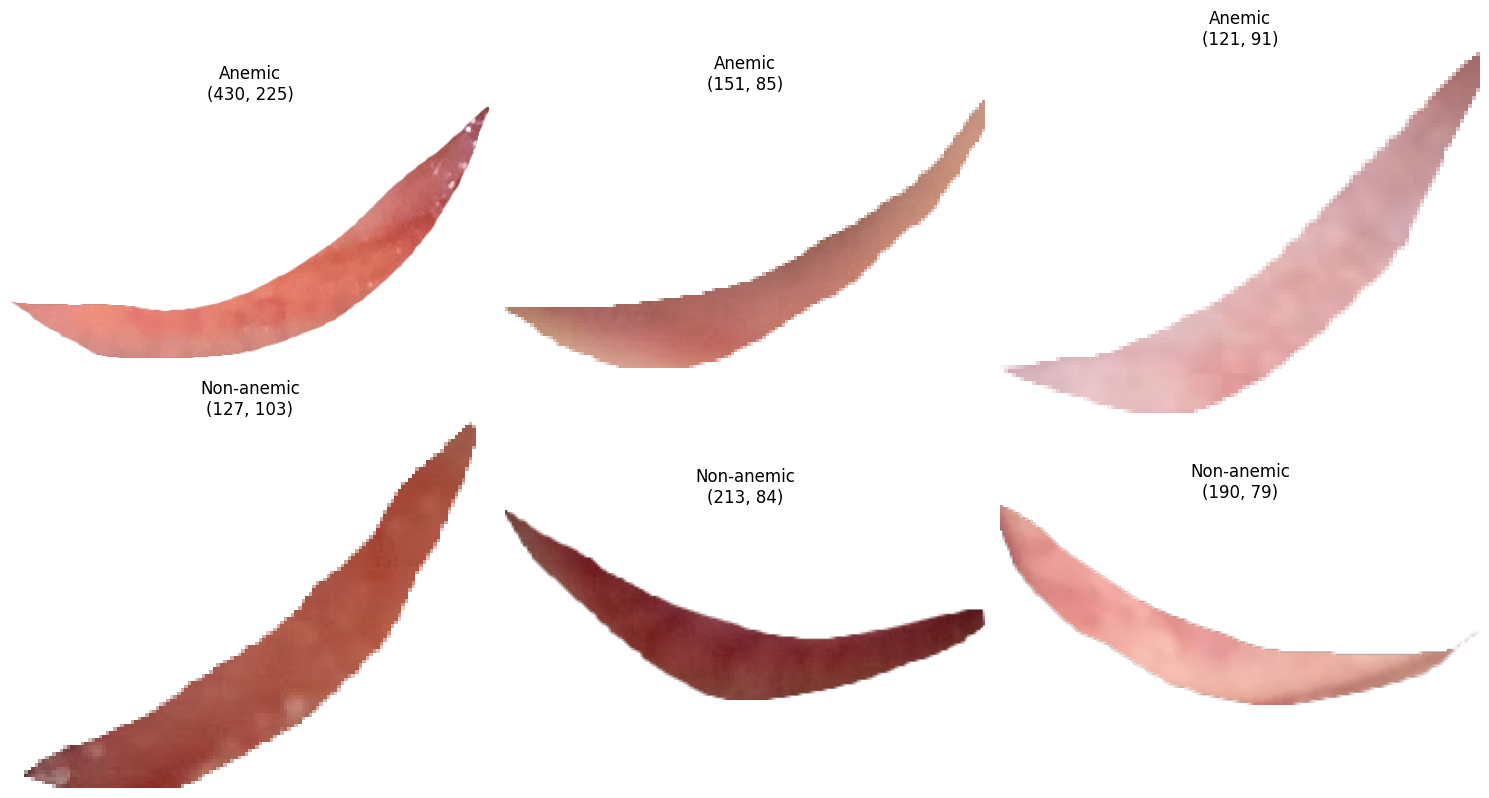

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Select 3 random Anemic and 3 random Non-Anemic images
random_anemic = random.sample(anemic_images, 3)
random_non_anemic = random.sample(non_anemic_images, 3)

sample_images = random_anemic + random_non_anemic

plt.figure(figsize=(15, 8))

for i, image_path in enumerate(sample_images):

    img = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"{image_path.parent.name}\n{img.size}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image

corrupted_images = []

# Check every image
for image_path in anemic_images + non_anemic_images:

    try:
        with Image.open(image_path) as img:
            img.verify()

    except Exception as e:
        corrupted_images.append((image_path.name, str(e)))

print("=" * 50)
print("CORRUPTED IMAGE CHECK")
print("=" * 50)

print(f"Total Images Checked : {len(anemic_images) + len(non_anemic_images)}")
print(f"Corrupted Images     : {len(corrupted_images)}")

if len(corrupted_images) == 0:
    print("\n✅ No corrupted images found.")
else:
    print("\nCorrupted Files:")
    for file, error in corrupted_images:
        print(file, ":", error)

CORRUPTED IMAGE CHECK
Total Images Checked : 710
Corrupted Images     : 0

✅ No corrupted images found.


In [ ]:
import hashlib
from collections import defaultdict

def calculate_md5(file_path):
    """
    Calculate the MD5 hash of a file.
    """
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# Dictionary to store hashes
hash_dict = defaultdict(list)

# Process all images
for image_path in anemic_images + non_anemic_images:
    image_hash = calculate_md5(image_path)
    hash_dict[image_hash].append(str(image_path))

# Find duplicate groups
duplicates = {h: files for h, files in hash_dict.items() if len(files) > 1}

print("=" * 60)
print("DUPLICATE IMAGE CHECK")
print("=" * 60)

print(f"Total Images Checked : {len(anemic_images) + len(non_anemic_images)}")
print(f"Duplicate Groups     : {len(duplicates)}")

if len(duplicates) == 0:
    print("\n✅ No exact duplicate images found.")
else:
    print("\nDuplicate Files:")
    for i, (_, files) in enumerate(duplicates.items(), start=1):
        print(f"\nGroup {i}")
        for file in files:
            print(file)

DUPLICATE IMAGE CHECK
Total Images Checked : 710
Duplicate Groups     : 91

Duplicate Files:

Group 1
/content/drive/MyDrive/Anemia_Project/Anemic/Image_013.png
/content/drive/MyDrive/Anemia_Project/Anemic/Image_087.png
/content/drive/MyDrive/Anemia_Project/Anemic/Image_085.png
/content/drive/MyDrive/Anemia_Project/Anemic/Image_086.png

Group 2
/content/drive/MyDrive/Anemia_Project/Anemic/Image_010.png
/content/drive/MyDrive/Anemia_Project/Anemic/Image_159.png

Group 3
/content/drive/MyDrive/Anemia_Project/Anemic/Image_021.png
/content/drive/MyDrive/Anemia_Project/Anemic/Image_125.png
/content/drive/MyDrive/Anemia_Project/Anemic/Image_172.png
/content/drive/MyDrive/Anemia_Project/Anemic/Image_109.png
/content/drive/MyDrive/Anemia_Project/Anemic/Image_082.png

Group 4
/content/drive/MyDrive/Anemia_Project/Anemic/Image_018.png
/content/drive/MyDrive/Anemia_Project/Anemic/Image_234.png
/content/drive/MyDrive/Anemia_Project/Anemic/Image_369.png
/content/drive/MyDrive/Anemia_Project/Anemic/

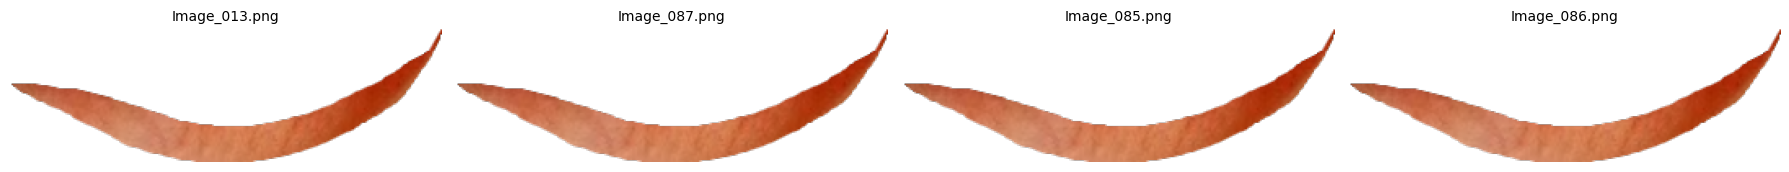

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Change this group number if you want to inspect another group
group_number = 1

duplicate_groups = list(duplicates.values())

selected_group = duplicate_groups[group_number - 1]

plt.figure(figsize=(18,4))

for i, file_path in enumerate(selected_group):

    img = Image.open(file_path)

    plt.subplot(1, len(selected_group), i+1)
    plt.imshow(img)
    plt.title(file_path.split("/")[-1], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

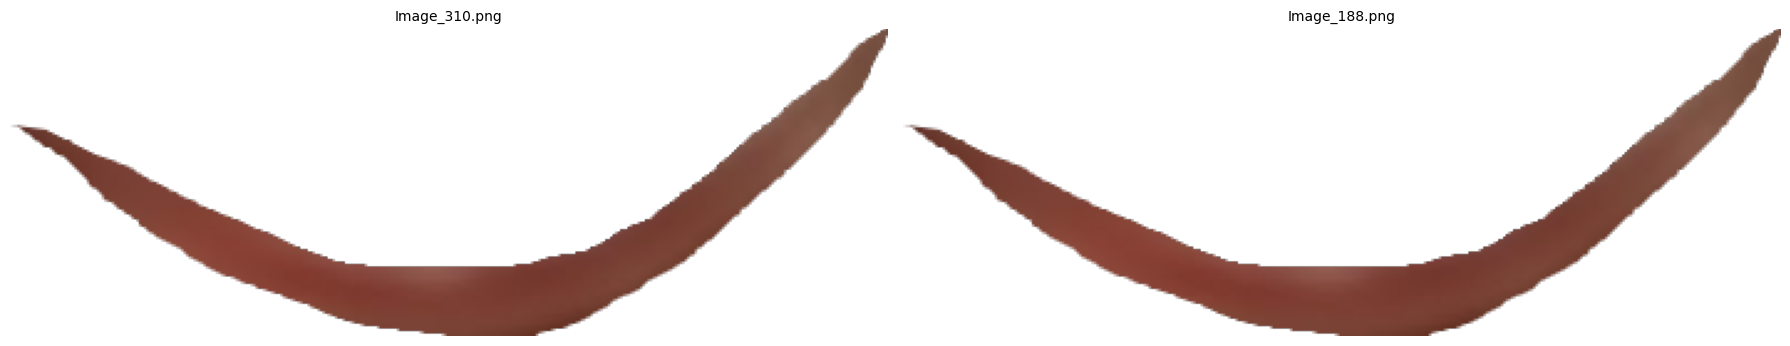

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Change this group number if you want to inspect another group
group_number = 51

duplicate_groups = list(duplicates.values())

selected_group = duplicate_groups[group_number - 1]

plt.figure(figsize=(18,4))

for i, file_path in enumerate(selected_group):

    img = Image.open(file_path)

    plt.subplot(1, len(selected_group), i+1)
    plt.imshow(img)
    plt.title(file_path.split("/")[-1], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
%whos DataFrame

Variable   Type         Data/Info
---------------------------------
df         DataFrame          IMAGE_ID  HB_LEVEL <...>\n[710 rows x 11 columns]


In [ ]:
# Check the metadata for the duplicate images

image_ids = ["Image_310", "Image_188"]

result = df[df["IMAGE_ID"].isin(image_ids)]

print(result)

      IMAGE_ID  HB_LEVEL    Severity  Age(Months)  GENDER      REMARK  \
187  Image_188     11.10  Non-Anemic            7  Female  Non-anemic   
309  Image_310      8.06    Moderate           12    Male      Anemic   

                             HOSPITAL     CITY/TOWN   MUNICIPALITY/DISTRICT  \
187         Manhyia District Hospital       Kumasi      Kumasi Metropolitan   
309  Nkawie-Toase Government Hospital  Nkawie-Toase  Atwima Nwabiagya South   

      REGION COUNTRY  
187  Ashanti   Ghana  
309  Ashanti   Ghana  


In [ ]:
# Display all columns without truncation

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

image_ids = ["Image_310", "Image_188"]

display(df[df["IMAGE_ID"].isin(image_ids)])

,IMAGE_ID,HB_LEVEL,Severity,Age(Months),GENDER,REMARK,HOSPITAL,CITY/TOWN,MUNICIPALITY/DISTRICT,REGION,COUNTRY
187,Image_188,11.10,Non-Anemic,7,Female,Non-anemic,Manhyia District Hospital,Kumasi,Kumasi Metropolitan,Ashanti,Ghana
309,Image_310,8.06,Moderate,12,Male,Anemic,Nkawie-Toase Government Hospital,Nkawie-Toase,Atwima Nwabiagya South,Ashanti,Ghana


In [ ]:
from pathlib import Path
import pandas as pd

# Create a copy of the dataframe
metadata = df.copy()

# Get image IDs from folders
folder_records = []

for img in anemic_images:
    folder_records.append({
        "IMAGE_ID": img.stem,
        "FOLDER_LABEL": "Anemic"
    })

for img in non_anemic_images:
    folder_records.append({
        "IMAGE_ID": img.stem,
        "FOLDER_LABEL": "Non-anemic"
    })

folder_df = pd.DataFrame(folder_records)

# Merge with Excel
merged = folder_df.merge(
    metadata[["IMAGE_ID", "REMARK"]],
    on="IMAGE_ID",
    how="left"
)

print("="*60)
print("FOLDER vs EXCEL LABEL CHECK")
print("="*60)

print("\nTotal Images:", len(merged))

mismatch = merged[
    merged["FOLDER_LABEL"].str.lower() !=
    merged["REMARK"].str.lower()
]

print("Mismatched Labels:", len(mismatch))

display(mismatch.head(20))

FOLDER vs EXCEL LABEL CHECK

Total Images: 710
Mismatched Labels: 0


,IMAGE_ID,FOLDER_LABEL,REMARK


# Step 3 – Create Image Manifest

**Objective**

Create a structured table containing every image path and its class label.

**Why?**

A manifest provides explicit control over dataset splitting, reproducibility, and inspection before training. It is a common practice in research-oriented machine learning workflows.

In [ ]:
from pathlib import Path
import pandas as pd

dataset_records = []

# Anemic images
for img_path in sorted(anemic_images):
    dataset_records.append({
        "image_id": img_path.stem,
        "image_path": str(img_path),
        "label": 1,
        "class_name": "Anemic"
    })

# Non-anemic images
for img_path in sorted(non_anemic_images):
    dataset_records.append({
        "image_id": img_path.stem,
        "image_path": str(img_path),
        "label": 0,
        "class_name": "Non-anemic"
    })

manifest_df = pd.DataFrame(dataset_records)

print("=" * 60)
print("IMAGE MANIFEST")
print("=" * 60)
print(f"Total Images : {len(manifest_df)}")
print(f"Columns      : {list(manifest_df.columns)}")

display(manifest_df.head())

IMAGE MANIFEST
Total Images : 710
Columns      : ['image_id', 'image_path', 'label', 'class_name']


,image_id,image_path,label,class_name
0,Image_001,/content/drive/MyDrive/Anemia_Project/Anemic/Image_001.png,1,Anemic
1,Image_002,/content/drive/MyDrive/Anemia_Project/Anemic/Image_002.png,1,Anemic
2,Image_005,/content/drive/MyDrive/Anemia_Project/Anemic/Image_005.png,1,Anemic
3,Image_007,/content/drive/MyDrive/Anemia_Project/Anemic/Image_007.png,1,Anemic
4,Image_009,/content/drive/MyDrive/Anemia_Project/Anemic/Image_009.png,1,Anemic


# Step 3.2 – Duplicate Statistics

**Objective**

Calculate the number of duplicate files and the number of unique images.

**Why?**

This helps us understand the extent of duplication before deciding how to handle it and allows us to document the dataset characteristics in the research paper.

In [ ]:
print("=" * 60)
print("DUPLICATE IMAGE STATISTICS")
print("=" * 60)

duplicate_files = 0

for group in duplicate_groups:
    duplicate_files += (len(group) - 1)

unique_images = len(manifest_df) - duplicate_files

print(f"Total Images           : {len(manifest_df)}")
print(f"Duplicate Groups       : {len(duplicate_groups)}")
print(f"Duplicate Files        : {duplicate_files}")
print(f"Estimated Unique Images: {unique_images}")

DUPLICATE IMAGE STATISTICS
Total Images           : 710
Duplicate Groups       : 91
Duplicate Files        : 212
Estimated Unique Images: 498


# Step 3.3 – Dataset Integrity Report

**Objective**

Analyze duplicate groups to determine whether duplicates occur only within the same class or across different classes.

**Why?**

Cross-class duplicates represent contradictory labels and must be identified before model training. This step ensures the integrity of the dataset and prevents label ambiguity.

In [ ]:
from pathlib import Path

cross_class_groups = []
same_class_groups = []

for group in duplicate_groups:
    classes = set()

    for img_path in group:
        parent = Path(img_path).parent.name
        classes.add(parent)

    if len(classes) == 1:
        same_class_groups.append(group)
    else:
        cross_class_groups.append(group)

print("=" * 60)
print("DATASET INTEGRITY REPORT")
print("=" * 60)

print(f"Total Duplicate Groups : {len(duplicate_groups)}")
print(f"Same-Class Groups      : {len(same_class_groups)}")
print(f"Cross-Class Groups     : {len(cross_class_groups)}")

if cross_class_groups:
    print("\nCross-Class Duplicate Groups:\n")
    for i, group in enumerate(cross_class_groups, 1):
        print(f"Group {i}")
        for img in group:
            print(img)
        print("-" * 40)

DATASET INTEGRITY REPORT
Total Duplicate Groups : 91
Same-Class Groups      : 90
Cross-Class Groups     : 1

Cross-Class Duplicate Groups:

Group 1
/content/drive/MyDrive/Anemia_Project/Anemic/Image_310.png
/content/drive/MyDrive/Anemia_Project/Non-anemic/Image_188.png
----------------------------------------


# Step 3 – Create Cleaned Dataset

## Objective

Create a cleaned copy of the dataset without modifying the original dataset.

## Why?

During dataset inspection, one cross-class duplicate group was identified. To ensure label consistency while preserving the original dataset, a new cleaned dataset will be created automatically.

The original dataset remains unchanged throughout the project.

In [ ]:
from pathlib import Path
import shutil

# -----------------------------
# Original Dataset Paths
# -----------------------------

original_dataset = Path("/content/drive/MyDrive/Anemia_Project")

anemic_src = original_dataset / "Anemic"
non_anemic_src = original_dataset / "Non-anemic"

# -----------------------------
# Cleaned Dataset Paths
# -----------------------------

cleaned_dataset = original_dataset / "Cleaned_Dataset"

cleaned_anemic = cleaned_dataset / "Anemic"
cleaned_non_anemic = cleaned_dataset / "Non-anemic"

# Create folders
cleaned_anemic.mkdir(parents=True, exist_ok=True)
cleaned_non_anemic.mkdir(parents=True, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


# Step 3.1 – Populate the Cleaned Dataset

## Objective

Copy all valid images into the cleaned dataset while excluding the identified cross-class duplicate pair.

## Why?

The original dataset is preserved. The cleaned dataset is automatically generated and will be used for all subsequent training and evaluation.

In [ ]:
from pathlib import Path
import shutil

# Images to exclude (cross-class contradictory duplicates)
exclude_images = {
    "Image_310.png",
    "Image_188.png"
}

# Counter variables
anemic_count = 0
non_anemic_count = 0
skipped = []

# -----------------------------
# Copy Anemic Images
# -----------------------------
for img in sorted(anemic_src.glob("*.png")):

    if img.name in exclude_images:
        skipped.append(img.name)
        continue

    shutil.copy2(img, cleaned_anemic / img.name)
    anemic_count += 1

# -----------------------------
# Copy Non-anemic Images
# -----------------------------
for img in sorted(non_anemic_src.glob("*.png")):

    if img.name in exclude_images:
        skipped.append(img.name)
        continue

    shutil.copy2(img, cleaned_non_anemic / img.name)
    non_anemic_count += 1

print("=" * 60)
print("CLEANED DATASET CREATED")
print("=" * 60)

print(f"Anemic Images     : {anemic_count}")
print(f"Non-anemic Images : {non_anemic_count}")
print(f"Total Images      : {anemic_count + non_anemic_count}")

print("\nSkipped Images:")
for s in skipped:
    print("-", s)

CLEANED DATASET CREATED
Anemic Images     : 423
Non-anemic Images : 285
Total Images      : 708

Skipped Images:
- Image_310.png
- Image_188.png


# Step 3.2 – Create Cleaned Dataset Manifest

## Objective

Generate a CSV file containing all images in the cleaned dataset.

## Why?

The manifest serves as the single source of truth for dataset splitting, model training, evaluation, and deployment. This improves reproducibility and simplifies experiment tracking.

In [ ]:
from pathlib import Path
import pandas as pd

records = []

cleaned_anemic = Path("/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic")
cleaned_non_anemic = Path("/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Non-anemic")

# Anemic
for img in sorted(cleaned_anemic.glob("*.png")):
    records.append({
        "image_id": img.stem,
        "image_path": str(img),
        "label": 1,
        "class_name": "Anemic"
    })

# Non-anemic
for img in sorted(cleaned_non_anemic.glob("*.png")):
    records.append({
        "image_id": img.stem,
        "image_path": str(img),
        "label": 0,
        "class_name": "Non-anemic"
    })

cleaned_manifest = pd.DataFrame(records)

manifest_path = "/content/drive/MyDrive/Anemia_Project/cleaned_manifest.csv"
cleaned_manifest.to_csv(manifest_path, index=False)

print("=" * 60)
print("CLEANED MANIFEST CREATED")
print("=" * 60)

print(f"Total Images : {len(cleaned_manifest)}")
print(f"Saved To     : {manifest_path}")

display(cleaned_manifest.head())

CLEANED MANIFEST CREATED
Total Images : 708
Saved To     : /content/drive/MyDrive/Anemia_Project/cleaned_manifest.csv


,image_id,image_path,label,class_name
0,Image_001,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_001.png,1,Anemic
1,Image_002,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_002.png,1,Anemic
2,Image_005,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_005.png,1,Anemic
3,Image_007,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_007.png,1,Anemic
4,Image_009,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_009.png,1,Anemic


# Step 4 – Create Stratified 5-Fold Cross Validation

## Objective

Split the cleaned dataset into five stratified folds.

## Why?

Medical datasets are usually small. Stratified 5-fold cross-validation provides a more reliable estimate of model performance while maintaining the class distribution in every fold.

In [ ]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd

# Step 4.1 – Assign Duplicate Group IDs

## Objective

Assign a unique group ID to every image.

Images belonging to the same duplicate group receive the same group ID.

## Why?

These group IDs are later used by StratifiedGroupKFold to ensure duplicate images are never split across different folds, preventing data leakage.

In [ ]:
import hashlib
from pathlib import Path

# Create image hash -> group mapping
hash_to_group = {}
image_to_group = {}

group_id = 0

for row in cleaned_manifest.itertuples():

    image_path = Path(row.image_path)

    with open(image_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    if file_hash not in hash_to_group:
        hash_to_group[file_hash] = group_id
        group_id += 1

    image_to_group[row.image_id] = hash_to_group[file_hash]

# Add group IDs to manifest
cleaned_manifest["group_id"] = cleaned_manifest["image_id"].map(image_to_group)

print("="*60)
print("GROUP ID ASSIGNMENT")
print("="*60)
print(f"Unique Groups : {cleaned_manifest['group_id'].nunique()}")
print(f"Total Images  : {len(cleaned_manifest)}")

display(cleaned_manifest.head())

GROUP ID ASSIGNMENT
Unique Groups : 497
Total Images  : 708


,image_id,image_path,label,class_name,group_id
0,Image_001,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_001.png,1,Anemic,0
1,Image_002,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_002.png,1,Anemic,1
2,Image_005,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_005.png,1,Anemic,2
3,Image_007,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_007.png,1,Anemic,3
4,Image_009,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_009.png,1,Anemic,4


# Step 4.2 – Verify Duplicate Group Distribution

## Objective

Verify how many images belong to each duplicate group.

## Why?

This confirms that duplicate grouping is correct before creating cross-validation folds.

In [ ]:
group_sizes = (
    cleaned_manifest
    .groupby("group_id")
    .size()
    .reset_index(name="images_in_group")
)

print("=" * 60)
print("GROUP SIZE DISTRIBUTION")
print("=" * 60)

print(group_sizes["images_in_group"].value_counts().sort_index())

print("\n")

print("Largest Duplicate Groups")

display(
    group_sizes.sort_values(
        by="images_in_group",
        ascending=False
    ).head(15)
)

GROUP SIZE DISTRIBUTION
images_in_group
1     407
2      38
3      25
4       9
5       7
6       5
7       3
8       1
10      2
Name: count, dtype: int64


Largest Duplicate Groups


,group_id,images_in_group
2,2,10
10,10,10
293,293,8
159,159,7
53,53,7
166,166,7
132,132,6
50,50,6
272,272,6
314,314,6


# Step 4.3 – Merge Clinical Metadata

## Objective

Merge the cleaned image manifest with the clinical metadata from the Excel sheet.

## Why?

The master manifest becomes the single source of truth for the entire project. It contains image paths, labels, duplicate group IDs, and clinical information required for future analysis and deployment.

In [ ]:
# ============================================================
# Merge Cleaned Manifest with Excel Metadata
# ============================================================

# Merge using IMAGE_ID from Excel and image_id from manifest
master_manifest = cleaned_manifest.merge(
    df,
    left_on="image_id",
    right_on="IMAGE_ID",
    how="left"
)

# Drop duplicate IMAGE_ID column
master_manifest.drop(columns=["IMAGE_ID"], inplace=True)

print("="*60)
print("MASTER MANIFEST CREATED")
print("="*60)

print(f"Rows    : {len(master_manifest)}")
print(f"Columns : {len(master_manifest.columns)}")

print("\nColumns:")
print(master_manifest.columns.tolist())

display(master_manifest.head())

MASTER MANIFEST CREATED
Rows    : 708
Columns : 15

Columns:
['image_id', 'image_path', 'label', 'class_name', 'group_id', 'HB_LEVEL', 'Severity', 'Age(Months)', 'GENDER', 'REMARK', 'HOSPITAL', 'CITY/TOWN', 'MUNICIPALITY/DISTRICT', 'REGION', 'COUNTRY']


,image_id,image_path,label,class_name,group_id,HB_LEVEL,Severity,Age(Months),GENDER,REMARK,HOSPITAL,CITY/TOWN,MUNICIPALITY/DISTRICT,REGION,COUNTRY
0,Image_001,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_001.png,1,Anemic,0,9.8,Moderate,6,Female,Anemic,Nkawie-Toase Government Hospital,Nkawie-Toase,Atwima Nwabiagya South,Ashanti,Ghana
1,Image_002,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_002.png,1,Anemic,1,9.9,Moderate,24,Male,Anemic,Ejusu Government Hospital,Ejusu,Ejusu Municipality,Ashanti,Ghana
2,Image_005,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_005.png,1,Anemic,2,9.9,Moderate,24,Male,Anemic,Sunyani Municipal Hospital,Sunyani,Sunyani Municipality,Bono,Ghana
3,Image_007,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_007.png,1,Anemic,3,9.9,Moderate,48,Female,Anemic,SDA Hospital,Sunyani,Sunyani Municipality,Bono,Ghana
4,Image_009,/content/drive/MyDrive/Anemia_Project/Cleaned_Dataset/Anemic/Image_009.png,1,Anemic,4,9.9,Moderate,36,Female,Anemic,Kintampo Municipal Hospital,Kintampo,Kintampo Municipality,Bono-East,Ghana


In [ ]:
# ============================================================
# Save Master Manifest
# ============================================================

master_manifest_path = "/content/drive/MyDrive/Anemia_Project/master_manifest.csv"

master_manifest.to_csv(master_manifest_path, index=False)

print("Master Manifest Saved Successfully!")
print(master_manifest_path)

Master Manifest Saved Successfully!
/content/drive/MyDrive/Anemia_Project/master_manifest.csv


# Step 4.4 – Verify Master Manifest

## Objective

Verify that the merged master manifest contains no missing clinical metadata.

## Why?

This ensures that every image has complete clinical information before creating the cross-validation folds.

In [ ]:
# ============================================================
# Verify Missing Values
# ============================================================

print("=" * 60)
print("MISSING VALUE CHECK")
print("=" * 60)

missing = master_manifest.isnull().sum()

print(missing)

print("\n")

if missing.sum() == 0:
    print("✅ No missing values found.")
else:
    print("⚠ Missing values detected.")

MISSING VALUE CHECK
image_id                 0
image_path               0
label                    0
class_name               0
group_id                 0
HB_LEVEL                 0
Severity                 0
Age(Months)              0
GENDER                   0
REMARK                   0
HOSPITAL                 0
CITY/TOWN                0
MUNICIPALITY/DISTRICT    0
REGION                   0
COUNTRY                  0
dtype: int64


✅ No missing values found.


# Step 5 – Create Hold-out Test Set

## Objective

Split the cleaned dataset into:

- Development Set (80%)
- Test Set (20%)

using Stratified Group Splitting.

## Why?

The test set remains completely unseen throughout model development, ensuring an unbiased final evaluation.

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

In [ ]:
# ============================================================
# Create Development and Test Set
# ============================================================

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Take only the first split
train_idx, test_idx = next(
    sgkf.split(
        master_manifest,
        y=master_manifest["label"],
        groups=master_manifest["group_id"]
    )
)

development_manifest = master_manifest.iloc[train_idx].reset_index(drop=True)
test_manifest = master_manifest.iloc[test_idx].reset_index(drop=True)

print("=" * 60)
print("DATASET SPLIT")
print("=" * 60)

print(f"Development Images : {len(development_manifest)}")
print(f"Test Images        : {len(test_manifest)}")

DATASET SPLIT
Development Images : 554
Test Images        : 154


In [ ]:
# ============================================================
# Class Distribution Check
# ============================================================

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

print("\nDevelopment Set")
print(development_manifest["class_name"].value_counts())

print("\nTest Set")
print(test_manifest["class_name"].value_counts())

CLASS DISTRIBUTION

Development Set
class_name
Anemic        322
Non-anemic    232
Name: count, dtype: int64

Test Set
class_name
Anemic        101
Non-anemic     53
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

seeds = [42, 100, 123, 2024, 999]

print("=" * 90)
print("COMPARISON OF DIFFERENT RANDOM SEEDS")
print("=" * 90)

for seed in seeds:

    sgkf = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    train_idx, test_idx = next(
        sgkf.split(
            master_manifest,
            y=master_manifest["label"],
            groups=master_manifest["group_id"]
        )
    )

    dev = master_manifest.iloc[train_idx]
    test = master_manifest.iloc[test_idx]

    dev_counts = dev["class_name"].value_counts()
    test_counts = test["class_name"].value_counts()

    print(f"\nSeed : {seed}")
    print(f"Development : {len(dev)} | Test : {len(test)}")

    print(
        f"Dev  -> Anemic: {dev_counts.get('Anemic',0)}, "
        f"Non-anemic: {dev_counts.get('Non-anemic',0)}"
    )

    print(
        f"Test -> Anemic: {test_counts.get('Anemic',0)}, "
        f"Non-anemic: {test_counts.get('Non-anemic',0)}"
    )

COMPARISON OF DIFFERENT RANDOM SEEDS

Seed : 42
Development : 554 | Test : 154
Dev  -> Anemic: 322, Non-anemic: 232
Test -> Anemic: 101, Non-anemic: 53

Seed : 100
Development : 554 | Test : 154
Dev  -> Anemic: 333, Non-anemic: 221
Test -> Anemic: 90, Non-anemic: 64

Seed : 123
Development : 562 | Test : 146
Dev  -> Anemic: 335, Non-anemic: 227
Test -> Anemic: 88, Non-anemic: 58

Seed : 2024
Development : 550 | Test : 158
Dev  -> Anemic: 319, Non-anemic: 231
Test -> Anemic: 104, Non-anemic: 54

Seed : 999
Development : 557 | Test : 151
Dev  -> Anemic: 337, Non-anemic: 220
Test -> Anemic: 86, Non-anemic: 65


# Step 5.1 – Verify No Data Leakage

## Objective

Verify that duplicate image groups are completely separated between the development and test sets.

## Why?

Images from the same duplicate group must never appear in both sets. This prevents data leakage and ensures unbiased model evaluation.

In [ ]:
# ============================================================
# Final Split (Seed = 123)
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

train_idx, test_idx = next(
    sgkf.split(
        master_manifest,
        y=master_manifest["label"],
        groups=master_manifest["group_id"]
    )
)

development_manifest = master_manifest.iloc[train_idx].reset_index(drop=True)
test_manifest = master_manifest.iloc[test_idx].reset_index(drop=True)

# ============================================================
# Leakage Check
# ============================================================

dev_groups = set(development_manifest["group_id"])
test_groups = set(test_manifest["group_id"])

common_groups = dev_groups.intersection(test_groups)

print("=" * 60)
print("DATA LEAKAGE CHECK")
print("=" * 60)

print(f"Development Groups : {len(dev_groups)}")
print(f"Test Groups        : {len(test_groups)}")
print(f"Shared Groups      : {len(common_groups)}")

if len(common_groups) == 0:
    print("\n✅ No duplicate group leakage detected.")
else:
    print("\n❌ Data leakage detected!")

DATA LEAKAGE CHECK
Development Groups : 397
Test Groups        : 100
Shared Groups      : 0

✅ No duplicate group leakage detected.


# Step 1 – Save Final Dataset Splits

## Objective

Save the finalized Development and Test manifests.

These files will serve as the source of truth for all future training, validation, and testing.

In [ ]:
# ============================================================
# Save Development and Test Manifest
# ============================================================

development_path = "/content/drive/MyDrive/Anemia_Project/development_manifest.csv"
test_path = "/content/drive/MyDrive/Anemia_Project/test_manifest.csv"

development_manifest.to_csv(development_path, index=False)
test_manifest.to_csv(test_path, index=False)

print("="*60)
print("DATASET SPLITS SAVED")
print("="*60)

print("Development Manifest")
print(development_path)

print()

print("Test Manifest")
print(test_path)

DATASET SPLITS SAVED
Development Manifest
/content/drive/MyDrive/Anemia_Project/development_manifest.csv

Test Manifest
/content/drive/MyDrive/Anemia_Project/test_manifest.csv
